In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

# --- SPECIFICA QUI I TUOI FILE ---
file_path_p1 = "/mnt/d/Datasets/mimic3_smart_cache/p000124/3644535_0010.pt" #3644535_0010.pt
file_path_p2 = "/mnt/d/Datasets/mimic3_smart_cache/p000298/3129212_0016.pt" 

def load_pt_file(path):
    if not os.path.exists(path):
        print(f"Errore: File non trovato in {path}")
        return None
    data = torch.load(path, map_location='cpu')
    # Convertiamo i tensori float16 in numpy float32 per facilità di analisi
    return {
        'ppg': data['ppg'].numpy().astype(np.float32),
        'ecg': data['ecg'].numpy().astype(np.float32)
    }

data_p1 = load_pt_file(file_path_p1)
data_p2 = load_pt_file(file_path_p2)

print("Dati caricati correttamente.")

Dati caricati correttamente.


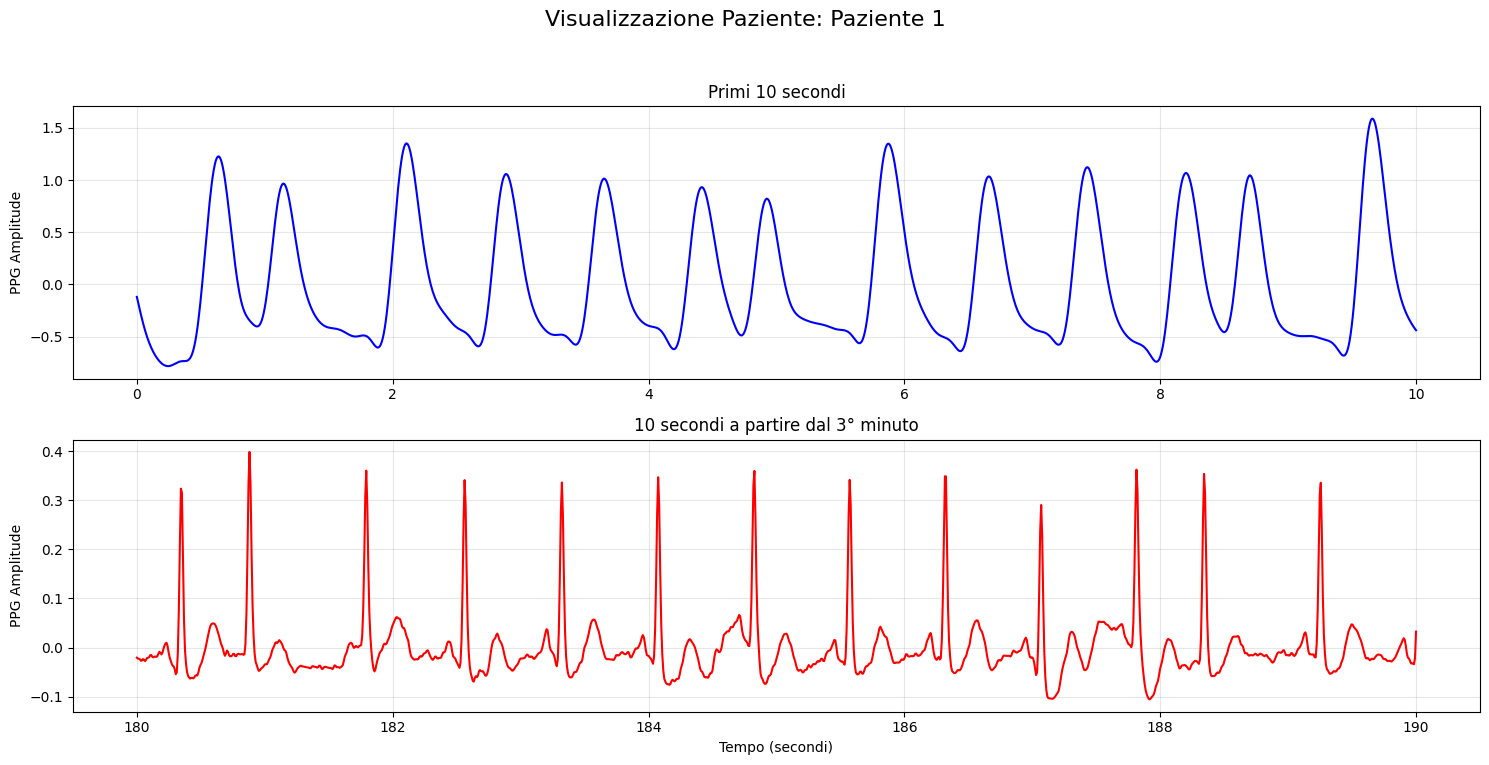

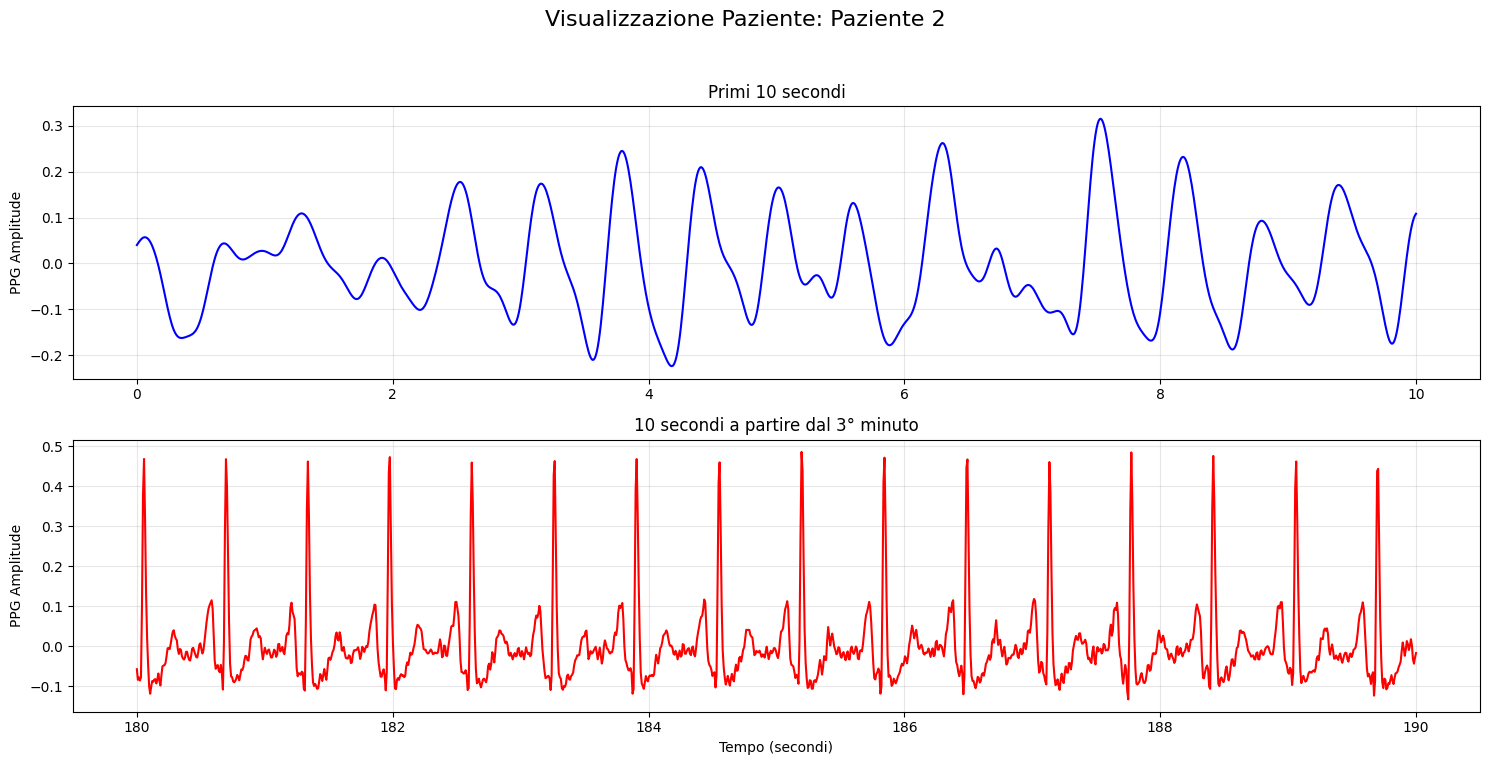

In [6]:
fs = 125 # Frequenza di campionamento MIMIC-III

def plot_segments(data, label):
    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=False)
    fig.suptitle(f"Visualizzazione Paziente: {label}", fontsize=16)
    
    # Segmento 1: Primi 10 secondi (0-1250 campioni)
    s1_start, s1_end = 0 * fs, 10 * fs
    axes[0].plot(np.linspace(0, 10, s1_end-s1_start), data['ppg'][s1_start:s1_end], color='blue')
    axes[0].set_title("Primi 10 secondi")
    axes[0].set_ylabel("PPG Amplitude")
    axes[0].grid(alpha=0.3)

    # Segmento 2: 10 secondi dal terzo minuto (180s - 190s)
    s2_start, s2_end = 180 * fs, 190 * fs
    axes[1].plot(np.linspace(180, 190, s2_end-s2_start), data['ecg'][s2_start:s2_end], color='red')
    axes[1].set_title("10 secondi a partire dal 3° minuto")
    axes[1].set_xlabel("Tempo (secondi)")
    axes[1].set_ylabel("PPG Amplitude")
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if data_p1: plot_segments(data_p1, "Paziente 1")
if data_p2: plot_segments(data_p2, "Paziente 2")

In [7]:
def print_stats(data, label):
    n_samples = len(data['ppg'])
    duration_sec = n_samples / fs
    duration_min = duration_sec / 60
    print(f"Statistiche {label}:")
    print(f"  - Numero campioni: {n_samples}")
    print(f"  - Durata totale: {duration_sec:.2f} secondi ({duration_min:.2f} minuti)")
    print("-" * 30)

if data_p1: print_stats(data_p1, "Paziente 1")
if data_p2: print_stats(data_p2, "Paziente 2")

Statistiche Paziente 1:
  - Numero campioni: 2222125
  - Durata totale: 17777.00 secondi (296.28 minuti)
------------------------------
Statistiche Paziente 2:
  - Numero campioni: 842326
  - Durata totale: 6738.61 secondi (112.31 minuti)
------------------------------


In [8]:
from scipy.signal import find_peaks
from scipy.stats import pearsonr

def check_ppg_quality(ppg_signal, fs=125, corr_threshold=0.90):
    # Controllo saturazione o segnale piatto
    if np.std(ppg_signal) < 0.01: return False
    
    # Normalizzazione e detrending veloce
    sig = (ppg_signal - np.mean(ppg_signal)) / (np.std(ppg_signal) + 1e-8)
    
    # Trova i picchi sistolici
    distance = int(fs * 0.4) # Max 150 BPM
    peaks, _ = find_peaks(sig, distance=distance, prominence=0.4)
    
    if len(peaks) < 5: return False # Troppo pochi battiti in 10s

    # Segmentazione e Resampling a lunghezza fissa per confronto
    beats = []
    for i in range(1, len(peaks)):
        beat = sig[peaks[i-1]:peaks[i]]
        if len(beat) > fs * 1.5 or len(beat) < fs * 0.3: continue
        # Resample a 100 punti
        beat_resampled = np.interp(np.linspace(0, 1, 100), np.linspace(0, 1, len(beat)), beat)
        beats.append(beat_resampled)

    if len(beats) < 3: return False

    # Template matching: quanto i battiti si somigliano?
    template = np.mean(beats, axis=0)
    corrs = [pearsonr(template, b)[0] for b in beats]
    
    return np.mean(corrs) > corr_threshold

def analyze_full_signal(data, window_sec=5, treshold=0.90):
    step = window_sec * fs
    signal = data['ppg']
    quality_mask = []
    
    for i in range(0, len(signal) - step, step):
        window = signal[i : i + step]
        is_good = check_ppg_quality(window, corr_threshold=treshold)
        quality_mask.append(is_good)
    
    return np.array(quality_mask)

In [9]:
def summarize_quality(mask_input, label):
    # Assicuriamoci che la maschera sia un array numpy per facilitare le operazioni logiche
    mask = np.array(mask_input)
    
    total_windows = len(mask)
    good_windows = np.sum(mask)
    bad_windows = total_windows - good_windows
    percent_good = (good_windows / total_windows) * 100
    
    print(f"Risultati Qualità per {label}:")
    print(f"  - Finestre totali (10s): {total_windows}")
    print(f"  - Finestre BUONE: {good_windows} ({percent_good:.2f}%)")
    print(f"  - Finestre SCARTATE (Rumore): {bad_windows}")
    
    # Plot della maschera di qualità nel tempo
    plt.figure(figsize=(15, 3)) # Aumentato leggermente l'altezza per chiarezza
    x_axis = np.arange(len(mask))
    
    # 1. Linea di contorno (grigia neutra per definire il passaggio)
    plt.step(x_axis, mask, where='post', color='gray', alpha=0.3, linewidth=1)
    
    # 2. Riempimento VERDE per le finestre BUONE (mask == 1)
    # fill_between riempie l'area sotto la curva definita da 'mask'
    plt.fill_between(x_axis, mask, step="post", alpha=0.5, color='green', label='Good Window (Attiva)')
    
    # 3. Riempimento ROSSO per le finestre CATTIVE (mask == 0)
    # Riempiamo l'area tra y=0 e y=1, ma SOLO dove la condizione (mask == 0) è vera
    plt.fill_between(x_axis, 0, 1, where=(mask == 0), step="post", alpha=0.5, color='red', label='Bad Window (Scartata)')
    
    plt.title(f"Maschera di Qualità nel Tempo - {label}")
    plt.xlabel("Indice Finestra (10s)")
    # Etichette dell'asse Y più chiare
    plt.yticks([0, 1], ['Bad (Rumore)', 'Good (Pulito)'])
    plt.grid(axis='x', alpha=0.2) # Grid solo verticale per pulizia
    plt.legend(loc='upper right', frameon=True)
    plt.xlim(0, len(mask)) # Assicura che il grafico inizi e finisca esattamente con i dati
    plt.tight_layout()
    plt.show()

Analisi qualità completata.
Risultati Qualità per Paziente 1:
  - Finestre totali (10s): 4444
  - Finestre BUONE: 3144 (70.75%)
  - Finestre SCARTATE (Rumore): 1300


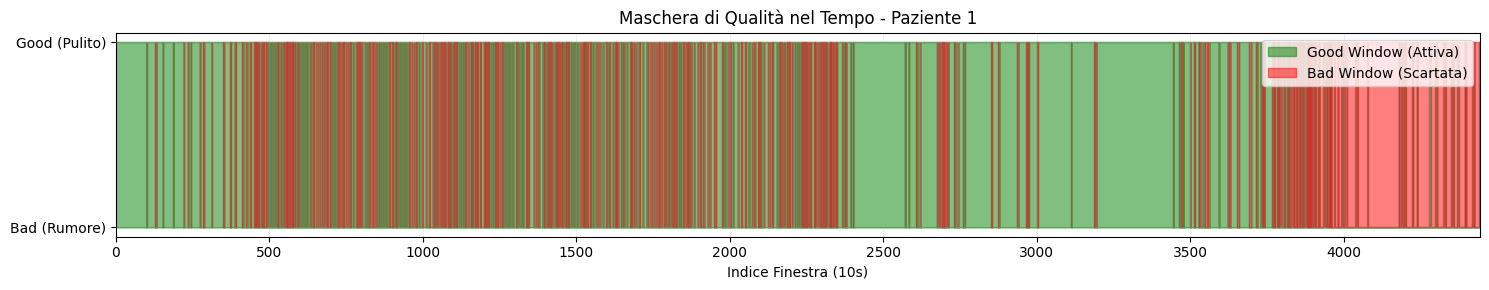

Risultati Qualità per Paziente 2:
  - Finestre totali (10s): 1684
  - Finestre BUONE: 906 (53.80%)
  - Finestre SCARTATE (Rumore): 778


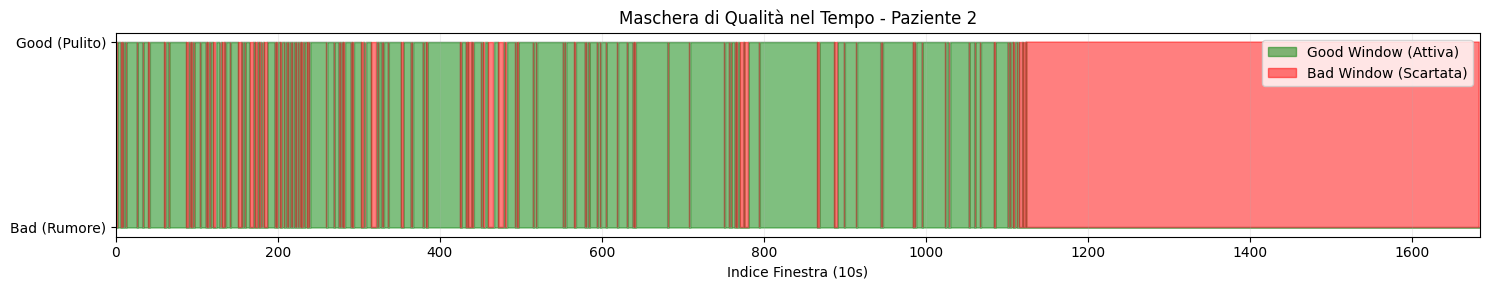

In [29]:
CORR_TRESHOLD = 0.9
mask_p1 = analyze_full_signal(data_p1, window_sec=4, treshold=CORR_TRESHOLD) if data_p1 else None
mask_p2 = analyze_full_signal(data_p2, window_sec=4, treshold=CORR_TRESHOLD) if data_p2 else None

print("Analisi qualità completata.")

if mask_p1 is not None: summarize_quality(mask_p1, "Paziente 1")
if mask_p2 is not None: summarize_quality(mask_p2, "Paziente 2")

### Metodo "Template Matching" (Il Gold Standard)
Questo è il metodo più robusto usato in letteratura (es. *Orphanidou et al.*). L'idea è: "Se il segnale è buono, i battiti all'interno della finestra devono assomigliarsi tra loro".

Come funziona:
* Si individuano i picchi del PPG nella finestra (es. 7 secondi).
* Si taglia il segnale in singoli battiti (beat segmentation).
* Si calcola un "battito medio" (template).
* Si calcola la correlazione di Pearson tra ogni singolo battito e il battito medio.
* Se la correlazione media è sotto una soglia (es. 0.9), il segnale è spazzatura.

Perché funziona: Gli artefatti da movimento sono caotici e non si ripetono uguali. Il battito cardiaco è ripetitivo.

In [10]:
def get_ppg_quality_score(ppg_signal, fs=125):
    """
    Versione della funzione che restituisce il valore numerico (score) 
    invece di un semplice True/False.
    """
    if np.std(ppg_signal) < 0.01: return 0.0
    
    sig = (ppg_signal - np.mean(ppg_signal)) / (np.std(ppg_signal) + 1e-8)
    distance = int(fs * 0.4)
    peaks, _ = find_peaks(sig, distance=distance, prominence=0.4)
    
    if len(peaks) < 4: return 0.0

    beats = []
    for i in range(1, len(peaks)):
        beat = sig[peaks[i-1]:peaks[i]]
        if len(beat) > fs * 1.5 or len(beat) < fs * 0.3: continue
        beat_resampled = np.interp(np.linspace(0, 1, 100), np.linspace(0, 1, len(beat)), beat)
        beats.append(beat_resampled)

    if len(beats) < 3: return 0.0

    template = np.mean(beats, axis=0)
    corrs = [pearsonr(template, b)[0] for b in beats]
    return np.mean(corrs)

In [25]:
def inspect_window(paziente_data, start_sec, win_sec, fs=125, threshold=0.85):
    """
    Estrae e visualizza una finestra di segnale PPG ed ECG, valutandone la qualità.
    
    Parametri:
    - paziente_data: dizionario con chiavi 'ppg' ed 'ecg'.
    - start_sec: istante di inizio in secondi.
    - win_sec: durata della finestra in secondi.
    - fs: frequenza di campionamento (default 125Hz).
    - threshold: soglia di correlazione per definire la qualità (default 0.85).
    """
    
    if paziente_data is None:
        print("Errore: Dati paziente non disponibili.")
        return

    # Calcolo indici
    start_idx = int(start_sec * fs)
    end_idx = int((start_sec + win_sec) * fs)
    
    # Controllo limiti
    if end_idx > len(paziente_data['ppg']):
        print(f"Errore: La finestra ({start_sec}s - {start_sec + win_sec}s) esce dai limiti del segnale.")
        return

    # Estrazione segmenti
    segment_ppg = paziente_data['ppg'][start_idx:end_idx]
    segment_ecg = paziente_data['ecg'][start_idx:end_idx]
    
    # Calcolo Qualità (usando la funzione definita precedentemente)
    score = get_ppg_quality_score(segment_ppg, fs)
    is_good = score > threshold
    
    # --- PLOTTING ---
    fig, axes = plt.subplots(2, 1, figsize=(5, 5), sharex=True)
    t_axis = np.linspace(start_sec, start_sec + win_sec, len(segment_ppg))
    
    # Colore e stato dinamico
    color_ppg = 'green' if is_good else 'red'
    status_text = "QUALITÀ: BUONA" if is_good else "QUALITÀ: RUMORE/SCARSA"
    
    # 1. Plot PPG
    axes[0].plot(t_axis, segment_ppg, color=color_ppg, label=f'PPG (Score: {score:.3f})')
    axes[0].set_title(f"Ispezione Finestra: {start_sec}s a {start_sec + win_sec}s", fontsize=14)
    axes[0].set_ylabel("PPG Amplitude")
    axes[0].legend(loc='upper right')
    axes[0].grid(alpha=0.3)
    
    # Box informativo
    axes[0].text(0.02, 0.9, f"{status_text}\nScore: {score:.3f}", 
                 transform=axes[0].transAxes, fontsize=12, fontweight='bold', 
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor=color_ppg))

    # 2. Plot ECG
    axes[1].plot(t_axis, segment_ecg, color='black', alpha=0.7, label='ECG Reale')
    axes[1].set_ylabel("ECG Amplitude")
    axes[1].set_xlabel("Tempo (s)")
    axes[1].legend(loc='upper right')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- ESEMPI DI RICHIAMO ---
# inspect_window(data_p1, start_sec=150, win_sec=10)
# inspect_window(data_p2, start_sec=300, win_sec=20, threshold=0.90)

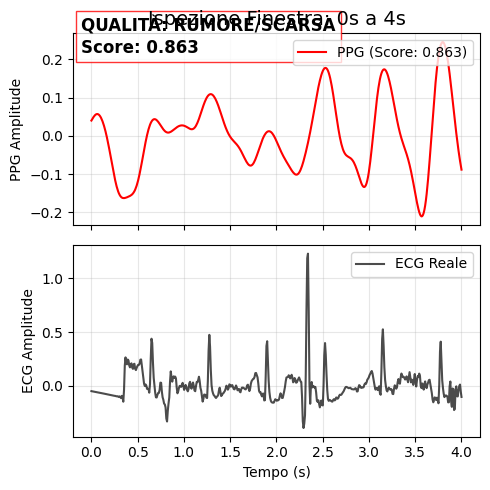

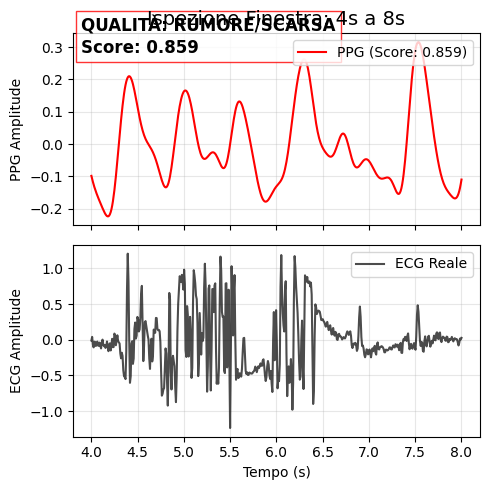

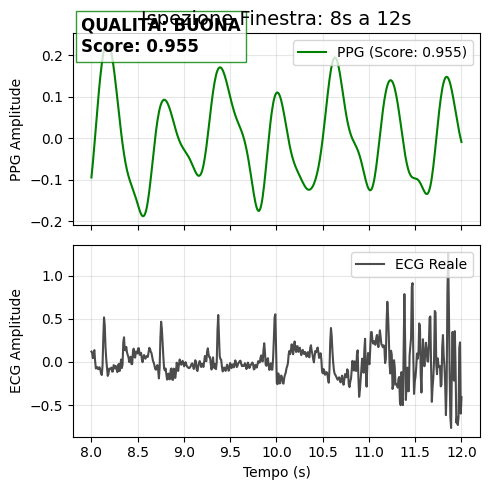

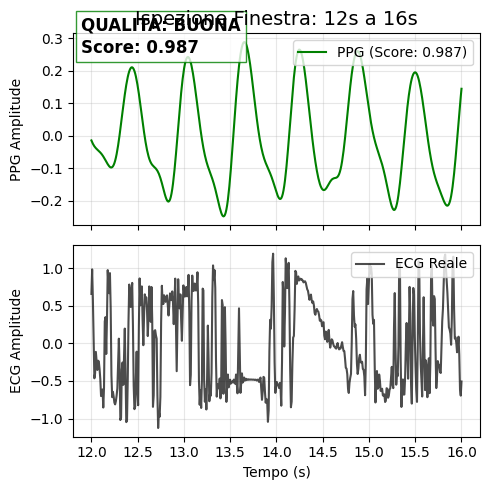

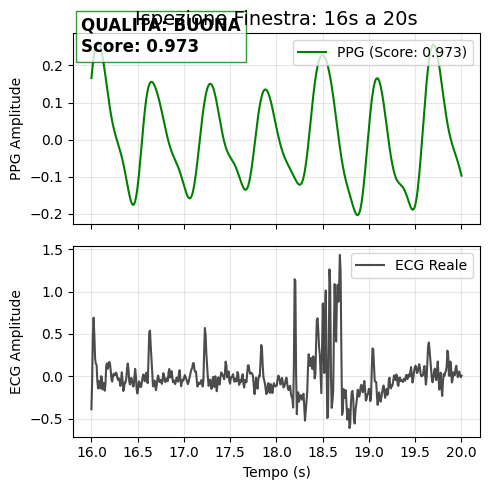

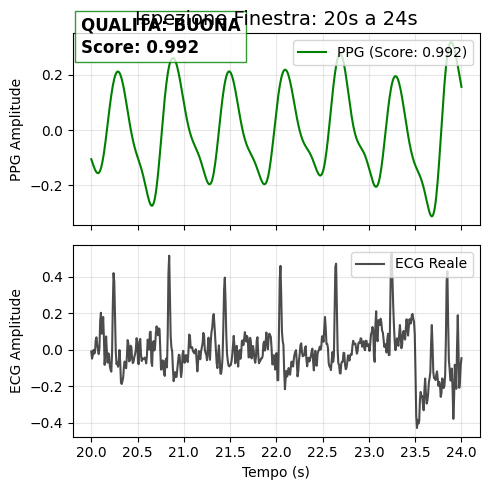

In [30]:
#inspect_window(data_p2, 0, 10, threshold=CORR_TRESHOLD)
CORR_TRESHOLD = 0.9
step_sec = 4
for start in range(0, 21, step_sec):
    inspect_window(data_p2, start, step_sec, threshold=CORR_TRESHOLD)
    

## Seconda Strategia - Sliding Windows

Per garantire un addestramento robusto e basato esclusivamente su segnali di alta qualità, è stata implementata una strategia di selezione basata su una sliding window con sovrapposizione. Il segnale PPG viene scansionato utilizzando finestre di ampiezza fissa ($win\_sec$, tipicamente 7 secondi) che scorrono lungo l'intero tracciato con un passo ridotto ($step\_sec$, ad esempio 1 secondo).

#### Criterio di Validità e Selezione
Ogni singola finestra viene valutata attraverso un algoritmo di Signal Quality Index (SQI) che assegna un punteggio di coerenza morfologica; una finestra viene ritenuta valida solo se il suo punteggio supera una soglia predefinita ($threshold = 0.85$), garantendo che il segnale non sia corrotto da artefatti da movimento o rumore elettronico.

#### Algoritmo di Merging
Per massimizzare l'utilità dei dati, le finestre valide che si sovrappongono o risultano adiacenti vengono aggregate attraverso un processo di merging. Questo permette di:
* **Creare segmenti continui**: Unire micro-finestre in blocchi temporali più estesi.
* **Filtrare frammenti inutili** : Identificare ed escludere porzioni di segnale troppo brevi per le necessità del modello.
* **Data Augmentation**: Sfruttare la sovrapposizione per generare molteplici esempi di training da un singolo tratto di segnale pulito.

Questa metodologia trasforma il dataset grezzo in una lista di intervalli di indici sicuri (start, end), pronti per essere campionati dal modello in fase di addestramento autoregressivo.

In [82]:
def sliding_window_analysis(data, win_sec=7, step_sec=1, fs=125, threshold=0.85):
    """
    Analizza il segnale con finestre sovrapposte e unisce gli intervalli validi.
    """
    ppg = data['ppg']
    win_samples = int(win_sec * fs)
    step_samples = int(step_sec * fs)
    
    total_windows = 0
    good_indices = [] # Salveremo tuple (start, end)
    
    # 1. Scorrimento del segnale
    for start in range(0, len(ppg) - win_samples, step_samples):
        total_windows += 1
        end = start + win_samples
        window = ppg[start:end]
        
        # Usiamo la funzione di qualità definita in precedenza
        score = get_ppg_quality_score(window, fs)
        
        if score > threshold:
            good_indices.append([start, end])
            
    if not good_indices:
        return [], total_windows, 0

    # 2. Merging degli intervalli
    # Ordiniamo per inizio (già ordinati dal loop, ma per sicurezza)
    good_indices.sort(key=lambda x: x[0])
    
    merged_intervals = []
    curr_start, curr_end = good_indices[0]
    
    for next_start, next_end in good_indices[1:]:
        # Se la finestra successiva inizia prima o esattamente dove finisce la corrente
        if next_start <= curr_end:
            # Estendiamo l'intervallo corrente
            curr_end = max(curr_end, next_end)
        else:
            # C'è un buco: salviamo l'intervallo precedente e iniziamo uno nuovo
            merged_intervals.append((curr_start, curr_end))
            curr_start, curr_end = next_start, next_end
            
    # Aggiungiamo l'ultimo intervallo
    merged_intervals.append((curr_start, curr_end))
    
    return merged_intervals, total_windows, len(good_indices)

def print_window_stats(total, kept, label):
    """
    Sostituisce il plot con un report testuale dettagliato.
    """
    discarded = total - kept
    # Calcolo percentuale con protezione per divisione per zero
    perc_kept = (kept / total * 100) if total > 0 else 0
    perc_discarded = (discarded / total * 100) if total > 0 else 0

    print(f"\n--- 📊 STATISTICHE FINESTRE: {label} ---")
    print(f"  • Intervalli totali analizzati: {total}")
    print(f"  • Numero di intervalli tenuti:  {kept} ({perc_kept:.2f}%) ✅")
    print(f"  • Numero di intervalli scartati: {discarded} ({perc_discarded:.2f}%) ❌")
    print("-" * (36 + len(label)))

def plot_specific_intervals(paziente_data, valid_intervals, indices_to_plot, fs=125):
    """
    Plotta una serie di intervalli specifici basandosi sui loro indici nella lista dei validi.
    
    Parametri:
    - paziente_data: Dizionario con 'ppg' e 'ecg'
    - valid_intervals: Lista di tuple (start_sample, end_sample)
    - indices_to_plot: Lista di interi (es. [0, 5, 10]) che indica quali intervalli visualizzare
    - fs: Frequenza di campionamento
    """
    
    if not valid_intervals:
        print("Errore: La lista degli intervalli validi è vuota.")
        return

    print(f"Generazione di {len(indices_to_plot)} plot richiesti...")

    for idx in indices_to_plot:
        # Controllo che l'indice esista nella lista degli intervalli
        if idx >= len(valid_intervals):
            print(f"Salto l'indice {idx}: fuori dal range della lista valid_intervals (lunghezza {len(valid_intervals)}).")
            continue
            
        # Recupero la tupla start/end
        start_idx, end_idx = valid_intervals[idx]
        
        # Estrazione dati
        segment_ppg = paziente_data['ppg'][start_idx:end_idx]
        segment_ecg = paziente_data['ecg'][start_idx:end_idx]
        
        # Asse temporale in secondi
        t_axis = np.linspace(start_idx / fs, end_idx / fs, len(segment_ppg))
        duration = (end_idx - start_idx) / fs
        
        # --- PLOTTING ---
        fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
        fig.suptitle(f"INTERVALLO #{idx} | Durata: {duration:.2f}s | Campioni: [{start_idx} : {end_idx}]", 
                     fontsize=14, fontweight='bold')
        
        # Subplot 1: PPG
        axes[0].plot(t_axis, segment_ppg, color='green', linewidth=1.2, label='PPG')
        axes[0].set_ylabel("PPG Amplitude")
        axes[0].set_title("Segnale PPG (Validato)")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc='upper right')
        
        # Subplot 2: ECG
        axes[1].plot(t_axis, segment_ecg, color='black', linewidth=1, alpha=0.8, label='ECG')
        axes[1].set_ylabel("ECG Amplitude")
        axes[1].set_xlabel("Tempo (secondi)")
        axes[1].set_title("Segnale ECG Corrispondente")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='upper right')
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
# --- ESEMPIO DI UTILIZZO ---
# plot_valid_intervals(intervals_p1, data_p1, max_plots=3)

In [31]:

# --- ESECUZIONE ---
# Parametri: finestra da 7s (come il modello) che scorre ogni 1s
WINDOW_SIZE = 4 
SLIDING_STEP = 1
THRESHOLD = 0.90
if data_p1:
    intervals_p1, total_p1, kept_p1 = sliding_window_analysis(data_p1, win_sec=WINDOW_SIZE, step_sec=SLIDING_STEP, threshold=THRESHOLD)
    print_window_stats(total_p1, kept_p1, "Paziente 1")
    print(f"Paziente 1: Trovati {len(intervals_p1)} segmenti continui dopo il merging.")

if data_p2:
    intervals_p2, total_p2, kept_p2 = sliding_window_analysis(data_p2, win_sec=WINDOW_SIZE, step_sec=SLIDING_STEP, threshold=THRESHOLD)
    print_window_stats(total_p2, kept_p2, "Paziente 2")
    print(f"Paziente 2: Trovati {len(intervals_p2)} segmenti continui dopo il merging.")


--- 📊 STATISTICHE FINESTRE: Paziente 1 ---
  • Intervalli totali analizzati: 17773
  • Numero di intervalli tenuti:  17081 (96.11%) ✅
  • Numero di intervalli scartati: 692 (3.89%) ❌
----------------------------------------------
Paziente 1: Trovati 95 segmenti continui dopo il merging.

--- 📊 STATISTICHE FINESTRE: Paziente 2 ---
  • Intervalli totali analizzati: 6735
  • Numero di intervalli tenuti:  3682 (54.67%) ✅
  • Numero di intervalli scartati: 3053 (45.33%) ❌
----------------------------------------------
Paziente 2: Trovati 96 segmenti continui dopo il merging.


Generazione di 3 plot richiesti...


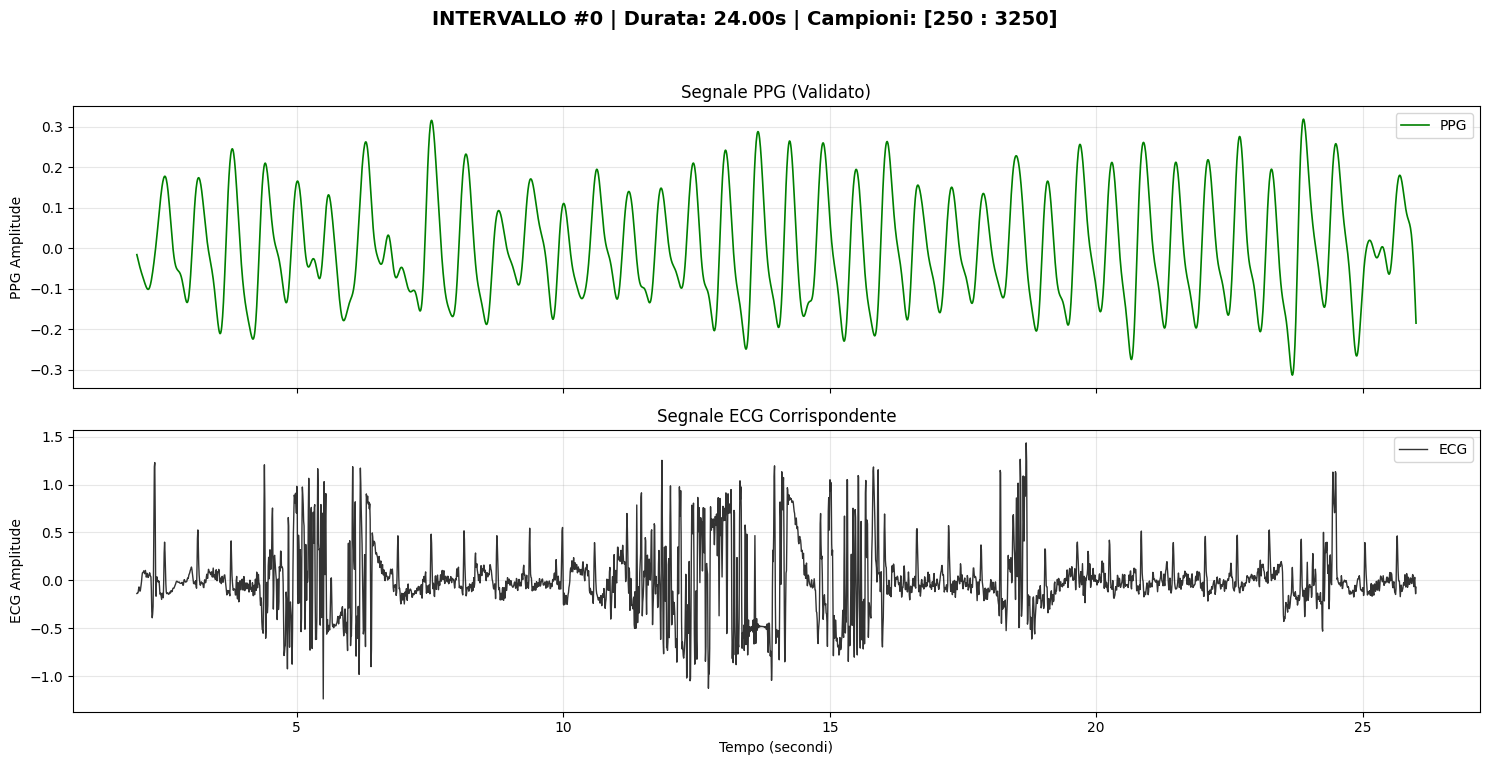

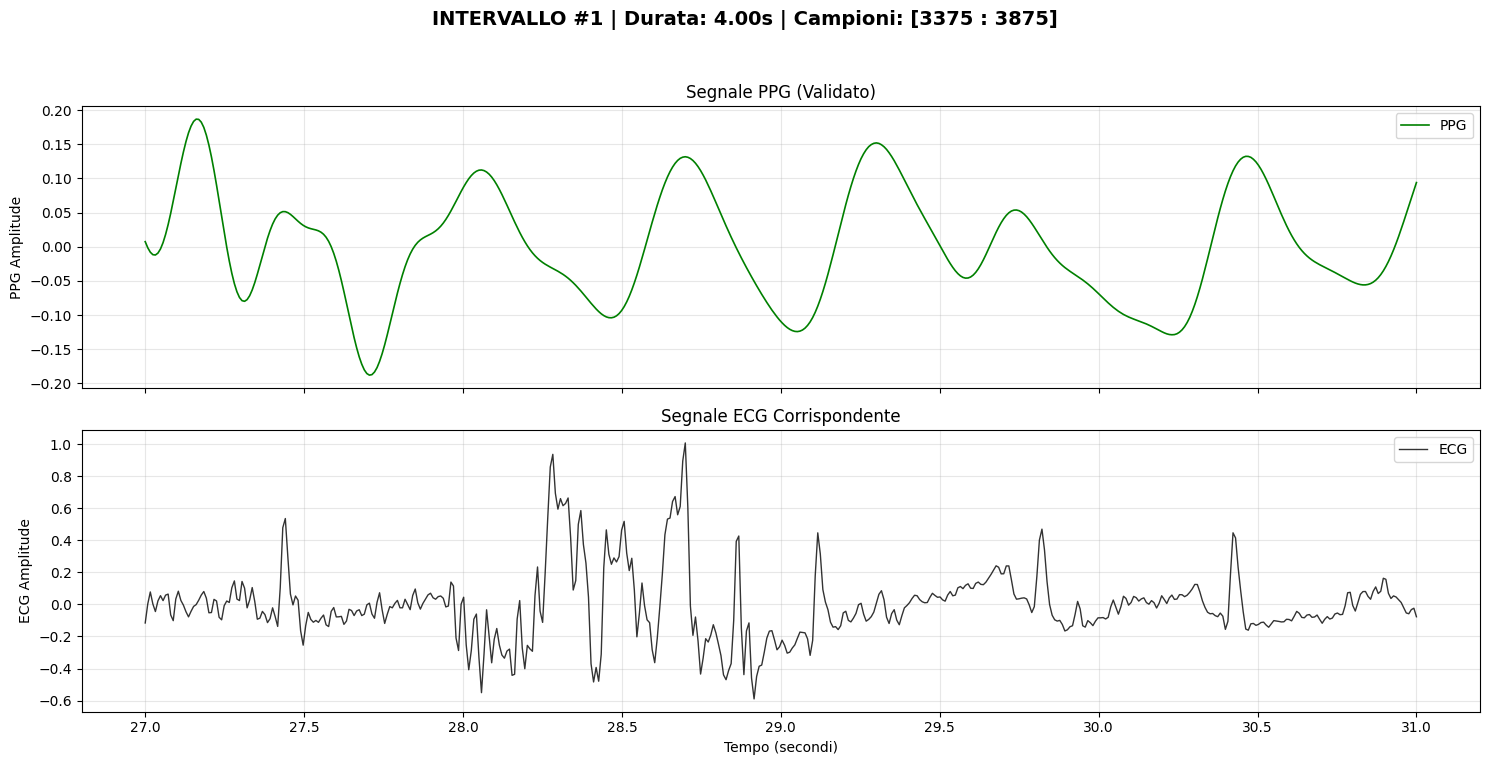

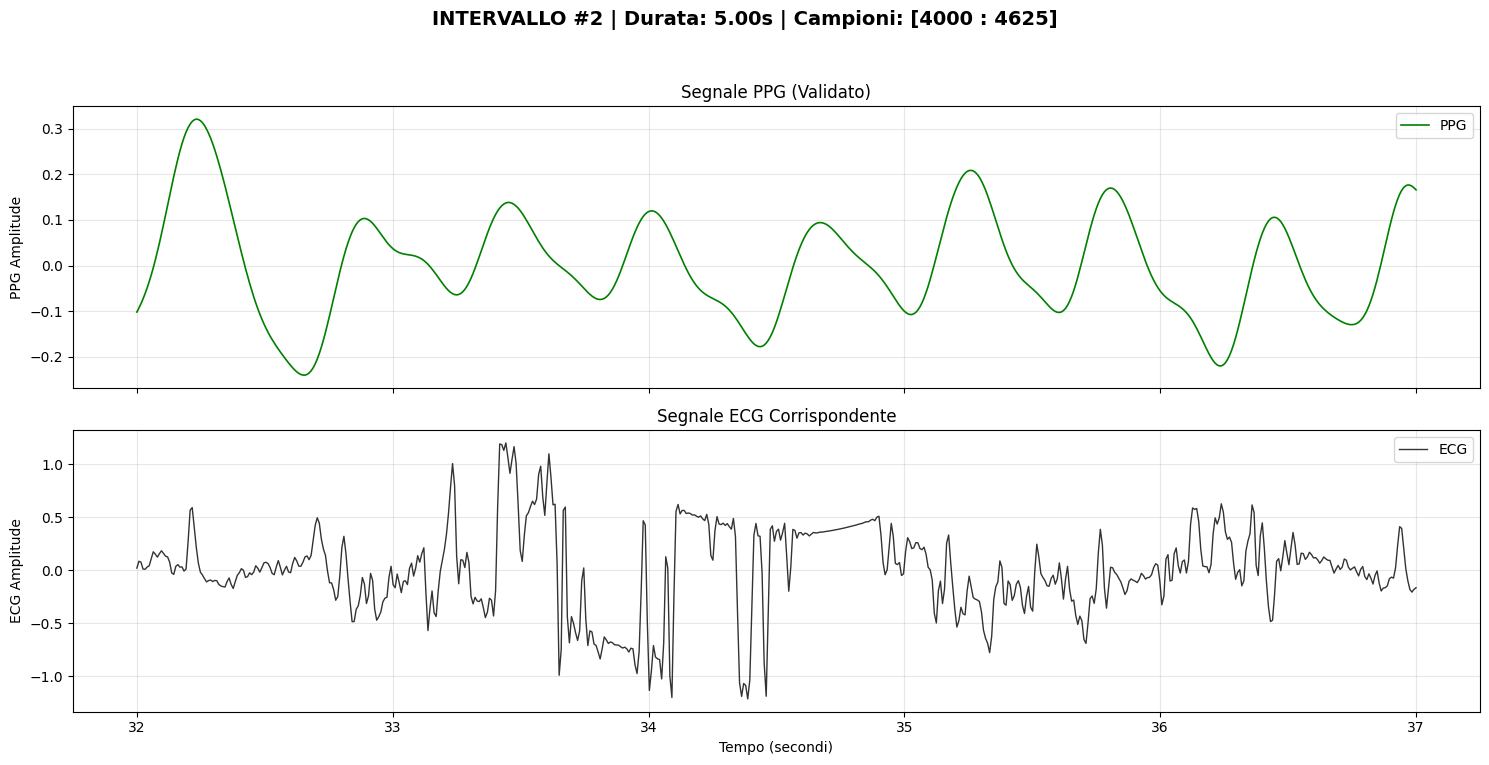

In [32]:
indici_richiesti = [0, 1, 2]
plot_specific_intervals(data_p2, intervals_p2, indici_richiesti)

In [ ]:
def analyze_short_intervals(intervals_list, threshold_sec=7, fs=125, label="Paziente"):
    """
    Calcola la percentuale di intervalli corti e la durata totale del segnale utile.
    """
    if not intervals_list:
        print(f"Nessun intervallo da analizzare per {label}.")
        return

    total_intervals = len(intervals_list)
    threshold_samples = threshold_sec * fs
    
    # 1. Filtriamo gli intervalli
    short_intervals = [intv for intv in intervals_list if (intv[1] - intv[0]) < threshold_samples]
    useful_intervals = [intv for intv in intervals_list if (intv[1] - intv[0]) >= threshold_samples]
    
    num_short = len(short_intervals)
    num_useful = len(useful_intervals)
    
    # 2. Calcolo durate utili
    # Sommiamo la durata di ogni segmento utile: (fine - inizio) / fs
    total_useful_samples = sum([(intv[1] - intv[0]) for intv in useful_intervals])
    total_useful_sec = total_useful_samples / fs
    total_useful_min = total_useful_sec / 60
    
    # 3. Calcolo percentuali
    perc_short = (num_short / total_intervals) * 100
    perc_useful = 100 - perc_short

    print(f"--- 📏 ANALISI LUNGHEZZA E DURATA: {label} ---")
    print(f"  • Soglia minima modello: {threshold_sec} secondi")
    print(f"  • Segmenti totali: {total_intervals}")
    print(f"  • Segmenti CORTI (<{threshold_sec}s): {num_short} ({perc_short:.2f}%) ⚠️")
    print(f"  • Segmenti UTILI (≥{threshold_sec}s): {num_useful} ({perc_useful:.2f}%) ✅")
    print(f"\n  👉 DURATA TOTALE DATI UTILI: {total_useful_sec:.2f} secondi")
    print(f"  👉 PARI A: {total_useful_min:.2f} minuti di segnale pulito")
    
    if num_short > 0:
        avg_short = np.mean([(intv[1] - intv[0]) / fs for intv in short_intervals])
        print(f"\n  • Info: La lunghezza media dei segmenti scartati è {avg_short:.2f}s")
    print("-" * 45)

# --- ESECUZIONE ---
THRESHOLD_MODELLO = 7 

if 'intervals_p1' in locals():
    analyze_short_intervals(intervals_p1, THRESHOLD_MODELLO, fs, "Paziente 1")

if 'intervals_p2' in locals():
    analyze_short_intervals(intervals_p2, THRESHOLD_MODELLO, fs, "Paziente 2")

--- 📏 ANALISI LUNGHEZZA E DURATA: Paziente 1 ---
  • Soglia minima modello: 7 secondi
  • Segmenti totali: 95
  • Segmenti CORTI (<7s): 5 (5.26%) ⚠️
  • Segmenti UTILI (≥7s): 90 (94.74%) ✅

  👉 DURATA TOTALE DATI UTILI: 17468.00 secondi
  👉 PARI A: 291.13 minuti di segnale pulito

  • Info: La lunghezza media dei segmenti scartati è 5.00s
---------------------------------------------
--- 📏 ANALISI LUNGHEZZA E DURATA: Paziente 2 ---
  • Soglia minima modello: 7 secondi
  • Segmenti totali: 96
  • Segmenti CORTI (<7s): 31 (32.29%) ⚠️
  • Segmenti UTILI (≥7s): 65 (67.71%) ✅

  👉 DURATA TOTALE DATI UTILI: 4028.00 secondi
  👉 PARI A: 67.13 minuti di segnale pulito

  • Info: La lunghezza media dei segmenti scartati è 4.77s
---------------------------------------------


# ECG

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

# --- SPECIFICA QUI I TUOI FILE ---
file_path_p1 = "/mnt/d/Datasets/mimic3_smart_cache/p000124/3644535_0010.pt" #3644535_0010.pt
file_path_p2 = "/mnt/d/Datasets/mimic3_smart_cache/p000298/3129212_0016.pt" 

def load_pt_file(path):
    if not os.path.exists(path):
        print(f"Errore: File non trovato in {path}")
        return None
    data = torch.load(path, map_location='cpu')
    # Convertiamo i tensori float16 in numpy float32 per facilità di analisi
    return {
        'ppg': data['ppg'].numpy().astype(np.float32),
        'ecg': data['ecg'].numpy().astype(np.float32)
    }

data_p1 = load_pt_file(file_path_p1)
data_p2 = load_pt_file(file_path_p2)

print("Dati caricati correttamente.")

rimerimenti scientifici di questo tipo di selezione: *s. Clifford et al., Orphanidou et al.*

In [79]:
from scipy.stats import kurtosis
from scipy.signal import find_peaks
from scipy.stats import pearsonr

def get_ecg_quality_score(ecg_signal, fs=125, kurtosis_thr=5.0):
    """
    Calcola uno score di qualità per l'ECG.
    Soglia Kurtosis (k): > 5.0 per ECG sano (Fisher=False, Gaussiana=3).
    """
    # 1. Controllo base (Flatline o NaN)
    if np.std(ecg_signal) < 1e-4:
        return 0.0, "flatline"

    # 2. Analisi Statistica: Kurtosis
    # Fisher=False: la distribuzione normale ha valore 3.0. 
    # Un ECG pulito ha picchi QRS che portano la kurtosis verso valori > 5-10.
    k_val = kurtosis(ecg_signal, fisher=False)
    
    if k_val < kurtosis_thr:
        return 0.0, f"low_kurtosis ({k_val:.1f})"

    # 3. Analisi Morfologica: Template Matching sui QRS
    # Normalizzazione per facilitare la ricerca dei picchi
    sig_norm = (ecg_signal - np.mean(ecg_signal)) / (np.std(ecg_signal) + 1e-8)
    
    # Trova i picchi R (distanza minima 0.4s = ~150 bpm max)
    peaks, _ = find_peaks(sig_norm, distance=int(fs*0.4), height=1.5)
    
    if len(peaks) < 3:
        return 0.0, "too_few_peaks"

    # Segmentazione battiti (0.2s prima, 0.4s dopo il picco)
    beats = []
    pre, post = int(fs*0.2), int(fs*0.4)
    for p in peaks:
        if p - pre >= 0 and p + post < len(sig_norm):
            beats.append(sig_norm[p - pre : p + post])
    
    if len(beats) < 3:
        return 0.0, "insufficient_beats"

    # Creazione Template e Correlazione
    template = np.mean(beats, axis=0)
    corrs = [pearsonr(template, b)[0] for b in beats]
    avg_corr = np.mean(corrs)
    
    return avg_corr, "ok"

def sliding_window_ecg_analysis(data, win_sec=7, step_sec=1, fs=125, threshold=0.80):
    """
    Esegue l'analisi a finestre scorrevoli sull'ECG e unisce gli intervalli validi.
    """
    ecg = data['ecg']
    win_samples = int(win_sec * fs)
    step_samples = int(step_sec * fs)
    
    total_windows = 0
    good_indices = []
    
    for start in range(0, len(ecg) - win_samples, step_samples):
        total_windows += 1
        window = ecg[start : start + win_samples]
        
        score, _ = get_ecg_quality_score(window, fs)
        
        if score > threshold:
            good_indices.append([start, start + win_samples])
            
    if not good_indices:
        return [], total_windows, 0

    # Merging degli intervalli vicini
    good_indices.sort(key=lambda x: x[0])
    merged = []
    curr_start, curr_end = good_indices[0]
    
    for next_start, next_end in good_indices[1:]:
        if next_start <= curr_end:
            curr_end = max(curr_end, next_end)
        else:
            merged.append((curr_start, curr_end))
            curr_start, curr_end = next_start, next_end
    merged.append((curr_start, curr_end))
    
    return merged, total_windows, len(good_indices)

def print_ecg_analysis_report(total, kept, merged_list, label):
    discarded = total - kept
    perc_kept = (kept / total * 100) if total > 0 else 0
    
    print(f"\n--- ⚡ ANALISI QUALITÀ ECG: {label} ---")
    print(f"  • Finestre totali analizzate: {total}")
    print(f"  • Finestre ACCETTATE:        {kept} ({perc_kept:.2f}%) ✅")
    print(f"  • Finestre SCARTATE:         {discarded} ❌")
    print(f"  • Segmenti continui (merged): {len(merged_list)}")
    print("-" * 40)

In [85]:
# --- PARAMETRI ---
WINDOW_SIZE = 4       # Secondi (coerente con il tuo modello)
SLIDING_STEP = 1      # Secondi
CORR_THRESHOLD = 0.9 # Soglia di correlazione morfologica ECG

# Analisi Paziente 1
if data_p1:
    intervals_ecg_p1, total_p1, kept_p1 = sliding_window_ecg_analysis(
        data_p1, win_sec=WINDOW_SIZE, step_sec=SLIDING_STEP, threshold=CORR_THRESHOLD
    )
    print_ecg_analysis_report(total_p1, kept_p1, intervals_ecg_p1, "Paziente 1")

# Analisi Paziente 2
if data_p2:
    intervals_ecg_p2, total_p2, kept_p2 = sliding_window_ecg_analysis(
        data_p2, win_sec=WINDOW_SIZE, step_sec=SLIDING_STEP, threshold=CORR_THRESHOLD
    )
    print_ecg_analysis_report(total_p2, kept_p2, intervals_ecg_p2, "Paziente 2")

# --- SUGGERIMENTO DI ISPEZIONE ---
# Se vuoi vedere il primo intervallo ECG ritenuto buono del Paziente 1:
# if intervals_ecg_p1:
#     plot_specific_intervals(data_p1, intervals_ecg_p1, [0])


--- ⚡ ANALISI QUALITÀ ECG: Paziente 1 ---
  • Finestre totali analizzate: 17773
  • Finestre ACCETTATE:        15144 (85.21%) ✅
  • Finestre SCARTATE:         2629 ❌
  • Segmenti continui (merged): 234
----------------------------------------

--- ⚡ ANALISI QUALITÀ ECG: Paziente 2 ---
  • Finestre totali analizzate: 6735
  • Finestre ACCETTATE:        2624 (38.96%) ✅
  • Finestre SCARTATE:         4111 ❌
  • Segmenti continui (merged): 156
----------------------------------------


Generazione di 3 plot richiesti...


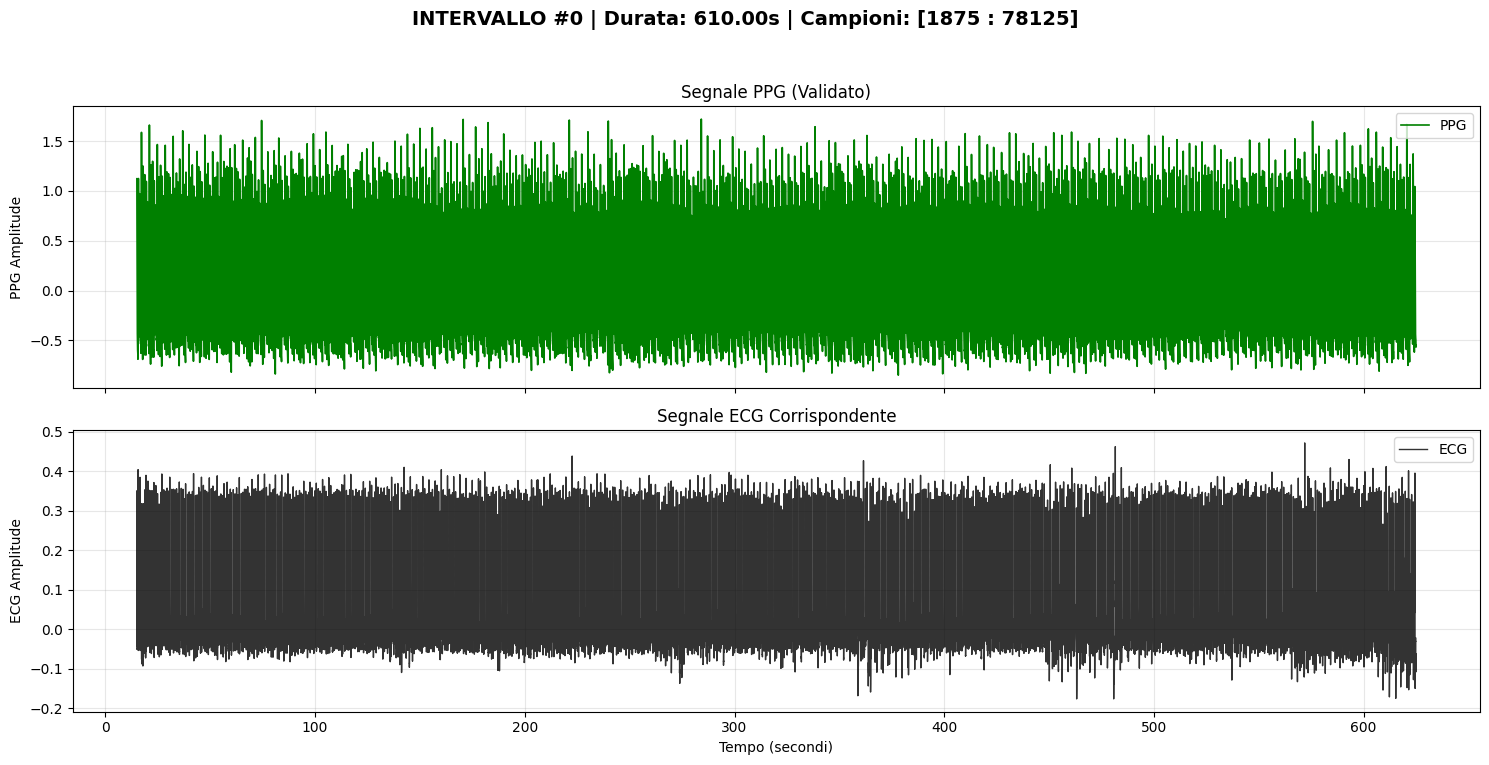

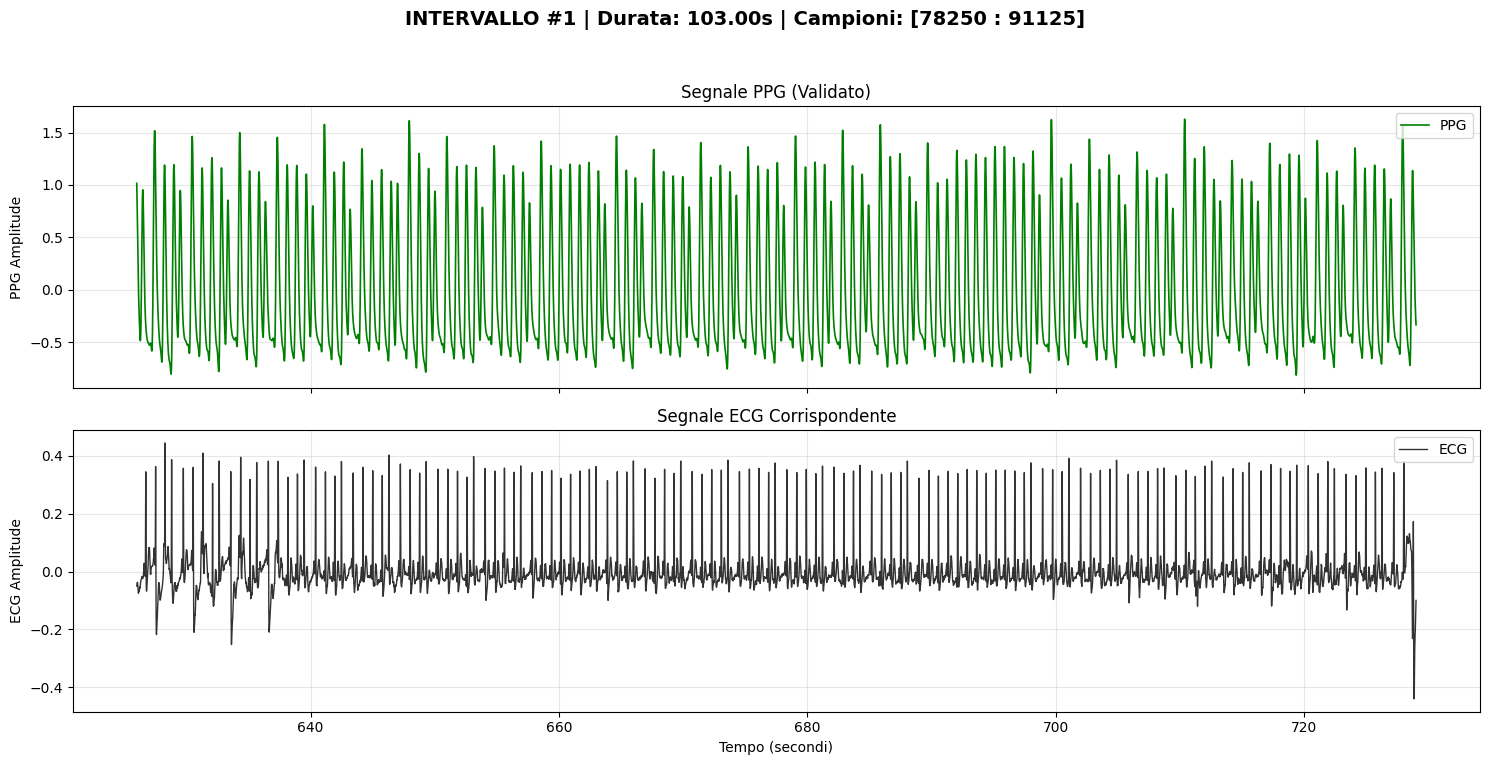

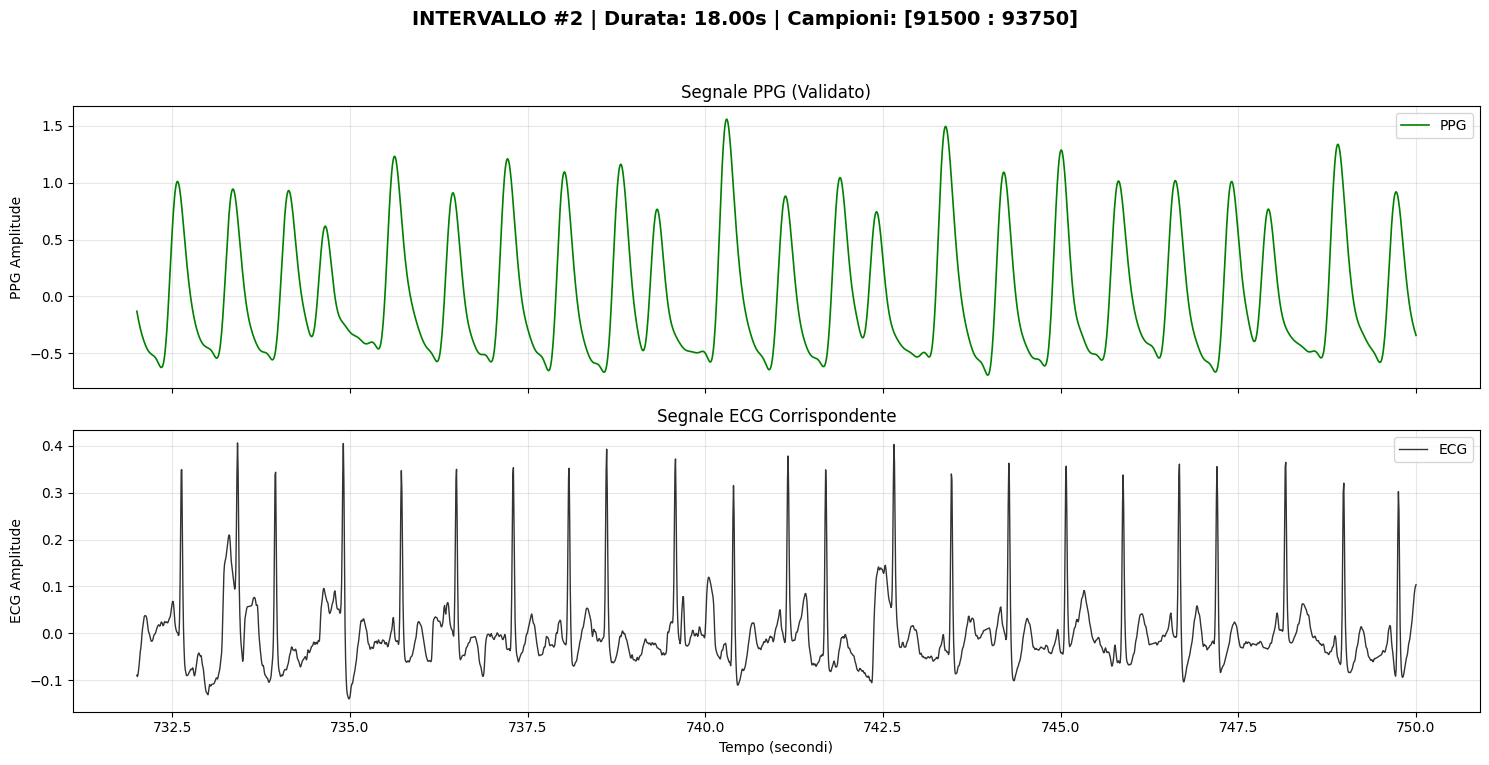

In [87]:
intervalli = [0,1,2]
plot_specific_intervals(data_p1, intervals_ecg_p1, intervalli)

# Controllo Incrociato

In [88]:
import numpy as np
from scipy.stats import kurtosis, pearsonr
from scipy.signal import find_peaks

def get_ppg_quality_score(ppg_signal, fs=125):
    """Analisi qualità PPG basata su Template Matching."""
    if np.std(ppg_signal) < 0.01: return 0.0
    sig = (ppg_signal - np.mean(ppg_signal)) / (np.std(ppg_signal) + 1e-8)
    peaks, _ = find_peaks(sig, distance=int(fs * 0.4), prominence=0.4)
    if len(peaks) < 4: return 0.0
    beats = []
    for i in range(1, len(peaks)):
        beat = sig[peaks[i-1]:peaks[i]]
        if fs * 0.3 < len(beat) < fs * 1.5:
            beats.append(np.interp(np.linspace(0, 1, 100), np.linspace(0, 1, len(beat)), beat))
    if len(beats) < 3: return 0.0
    template = np.mean(beats, axis=0)
    return np.mean([pearsonr(template, b)[0] for b in beats])

def get_ecg_quality_score(ecg_signal, fs=125, kurtosis_thr=5.0):
    """Analisi qualità ECG basata su Kurtosis e Template Matching."""
    if np.std(ecg_signal) < 1e-4: return 0.0
    k_val = kurtosis(ecg_signal, fisher=False)
    if k_val < kurtosis_thr: return 0.0
    sig_norm = (ecg_signal - np.mean(ecg_signal)) / (np.std(ecg_signal) + 1e-8)
    peaks, _ = find_peaks(sig_norm, distance=int(fs*0.4), height=1.5)
    if len(peaks) < 3: return 0.0
    beats = []
    pre, post = int(fs*0.2), int(fs*0.4)
    for p in peaks:
        if p - pre >= 0 and p + post < len(sig_norm):
            beats.append(sig_norm[p - pre : p + post])
    if len(beats) < 3: return 0.0
    template = np.mean(beats, axis=0)
    return np.mean([pearsonr(template, b)[0] for b in beats])

def merge_intervals(intervals):
    """Unisce intervalli sovrapposti o contigui."""
    if not intervals: return []
    intervals.sort(key=lambda x: x[0])
    merged = [intervals[0]]
    for next_start, next_end in intervals[1:]:
        curr_start, curr_end = merged[-1]
        if next_start <= curr_end:
            merged[-1] = (curr_start, max(curr_end, next_end))
        else:
            merged.append((next_start, next_end))
    return merged

def cross_check_analysis(data, win_sec=7, step_sec=1, fs=125, ppg_thr=0.85, ecg_thr=0.82):
    """Esegue analisi separata e poi combina i risultati."""
    total_samples = len(data['ppg'])
    win_samples = int(win_sec * fs)
    step_samples = int(step_sec * fs)
    
    ppg_good, ecg_good = [], []
    
    for start in range(0, total_samples - win_samples, step_samples):
        end = start + win_samples
        if get_ppg_quality_score(data['ppg'][start:end], fs) > ppg_thr:
            ppg_good.append((start, end))
        if get_ecg_quality_score(data['ecg'][start:end], fs) > ecg_thr:
            ecg_good.append((start, end))
            
    # Merging
    ppg_merged = merge_intervals(ppg_good)
    ecg_merged = merge_intervals(ecg_good)
    
    # Intersezione (Cross-check) tramite maschera booleana
    mask_ppg = np.zeros(total_samples, dtype=bool)
    for s, e in ppg_merged: mask_ppg[s:e] = True
    mask_ecg = np.zeros(total_samples, dtype=bool)
    for s, e in ecg_merged: mask_ecg[s:e] = True
    
    combined_mask = mask_ppg & mask_ecg
    
    # Converte maschera in intervalli (start, end)
    combined_intervals = []
    if np.any(combined_mask):
        diff = np.diff(combined_mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends = np.where(diff == -1)[0] + 1
        if combined_mask[0]: starts = np.insert(starts, 0, 0)
        if combined_mask[-1]: ends = np.append(ends, total_samples)
        combined_intervals = list(zip(starts, ends))
        
    return ppg_merged, ecg_merged, combined_intervals

def format_time(samples, fs=125):
    seconds = samples / fs
    return f"{int(seconds // 60)}m {int(seconds % 60)}s"

def print_cross_stats(data, ppg_int, ecg_int, comb_int, label, fs=125):
    print(f"\n{'='*50}\n📊 REPORT CROSS-CHECK: {label}\n{'='*50}")
    tot_s = len(data['ppg'])
    print(f"• Segnale Originale:      {format_time(tot_s, fs)} ({tot_s} campioni)")
    
    def get_info(intervals):
        dur = sum([e-s for s, e in intervals])
        return format_time(dur, fs), len(intervals)

    ppg_t, ppg_n = get_info(ppg_int)
    print(f"• PPG Valida (Analisi 1): {ppg_t} | {ppg_n} intervalli")
    
    ecg_t, ecg_n = get_info(ecg_int)
    print(f"• ECG Valida (Analisi 2): {ecg_t} | {ecg_n} intervalli")
    
    comb_t, comb_n = get_info(comb_int)
    print(f"\n⭐ COMBINATO (PPG+ECG):  {comb_t} | {comb_n} intervalli")
    print(f"{'='*50}")


📊 REPORT CROSS-CHECK: Paziente 1
• Segnale Originale:      296m 17s (2222125 campioni)
• PPG Valida (Analisi 1): 291m 33s | 95 intervalli
• ECG Valida (Analisi 2): 270m 34s | 234 intervalli

⭐ COMBINATO (PPG+ECG):  266m 29s | 308 intervalli
Generazione di 3 plot richiesti...


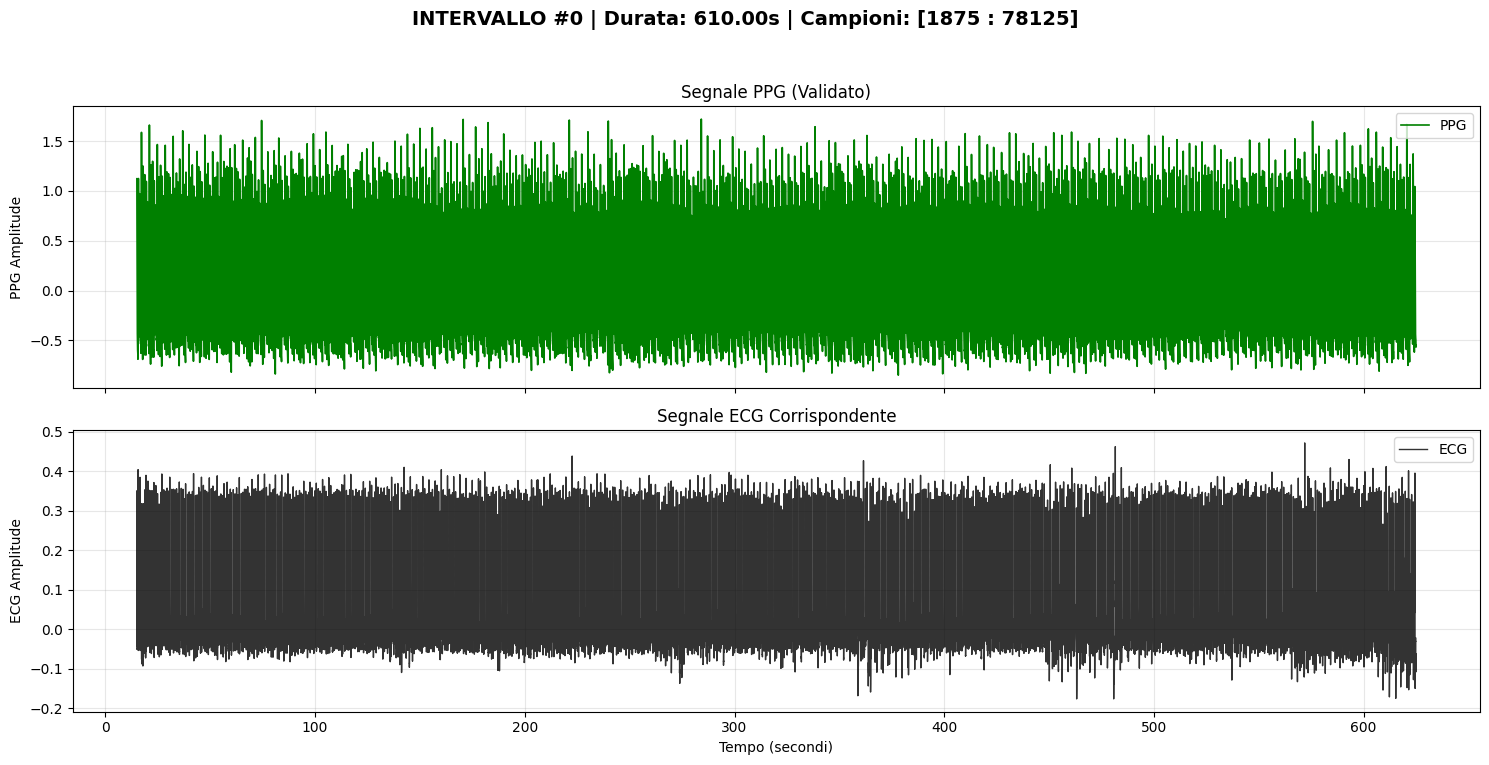

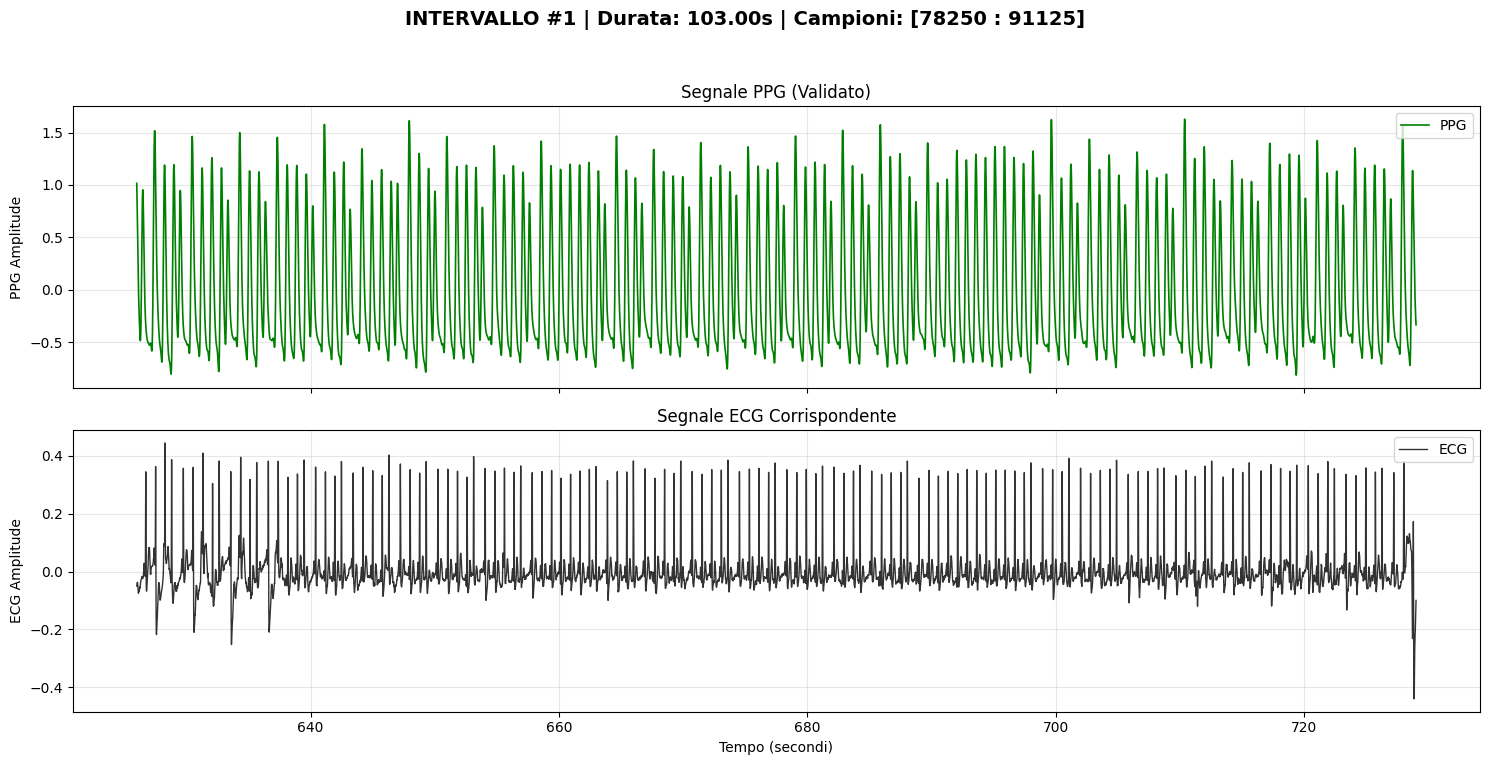

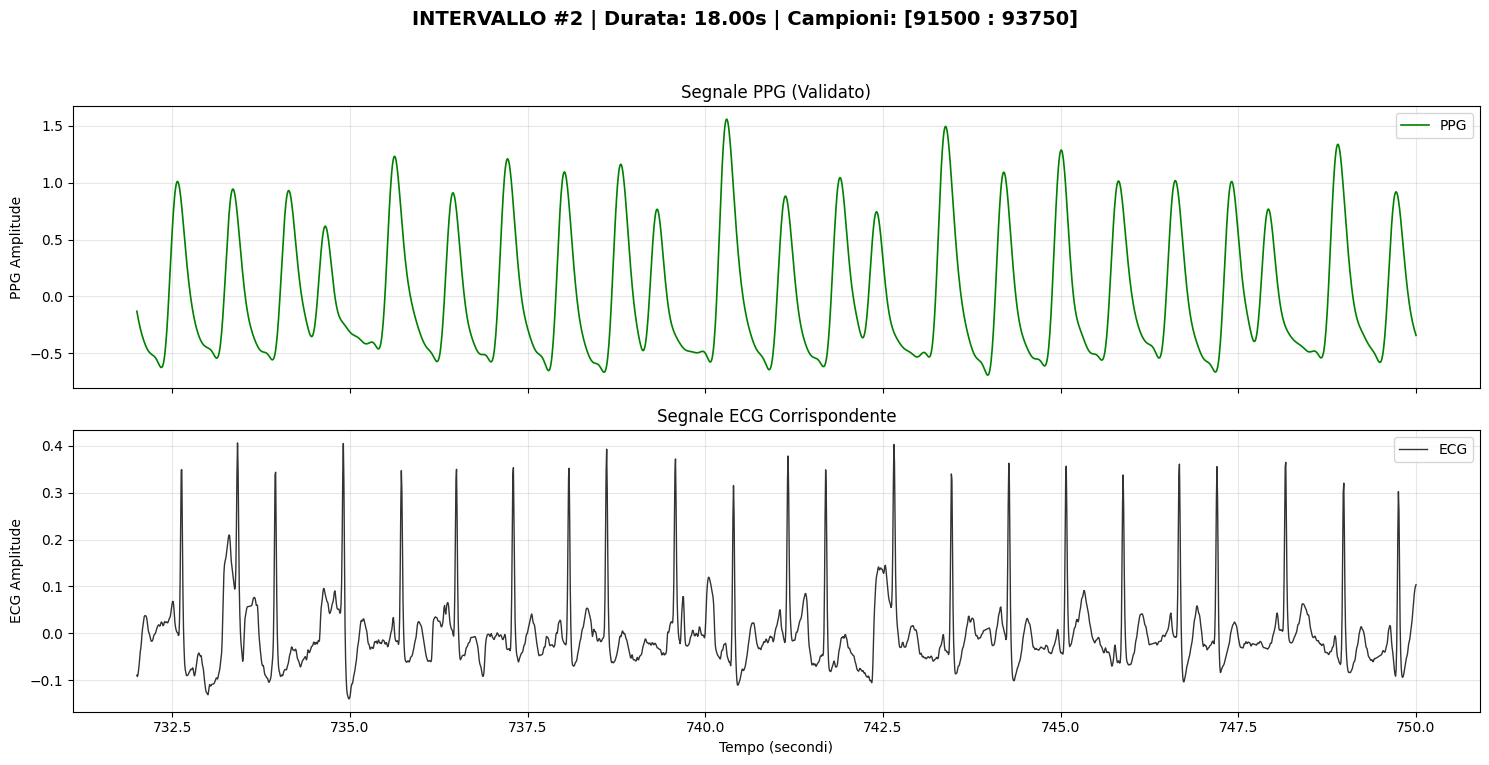

In [89]:
# --- PARAMETRI ---
WINDOW_SIZE = 4
SLIDING_STEP = 1
PPG_THRESHOLD = 0.9
ECG_THRESHOLD = 0.9

# Esecuzione analisi sul Paziente 1
if data_p1:
    ppg_i, ecg_i, comb_i = cross_check_analysis(
        data_p1, win_sec=WINDOW_SIZE, step_sec=SLIDING_STEP, 
        ppg_thr=PPG_THRESHOLD, ecg_thr=ECG_THRESHOLD
    )
    
    # Stampa Statistiche
    print_cross_stats(data_p1, ppg_i, ecg_i, comb_i, "Paziente 1")
    
    # Plotting degli intervalli combinati (es. i primi 3 utili)
    if comb_i:
        # Seleziona i primi 3 indici o quelli che desideri, es: [0, 1, 2]
        indici_da_plottare = list(range(min(3, len(comb_i))))
        plot_specific_intervals(data_p1, comb_i, indici_da_plottare)
    else:
        print("Nessun intervallo combinato trovato per il plotting.")


📊 REPORT CROSS-CHECK: Paziente 2
• Segnale Originale:      112m 18s (842326 campioni)
• PPG Valida (Analisi 1): 69m 36s | 96 intervalli
• ECG Valida (Analisi 2): 54m 6s | 156 intervalli

⭐ COMBINATO (PPG+ECG):  47m 49s | 174 intervalli
Generazione di 3 plot richiesti...


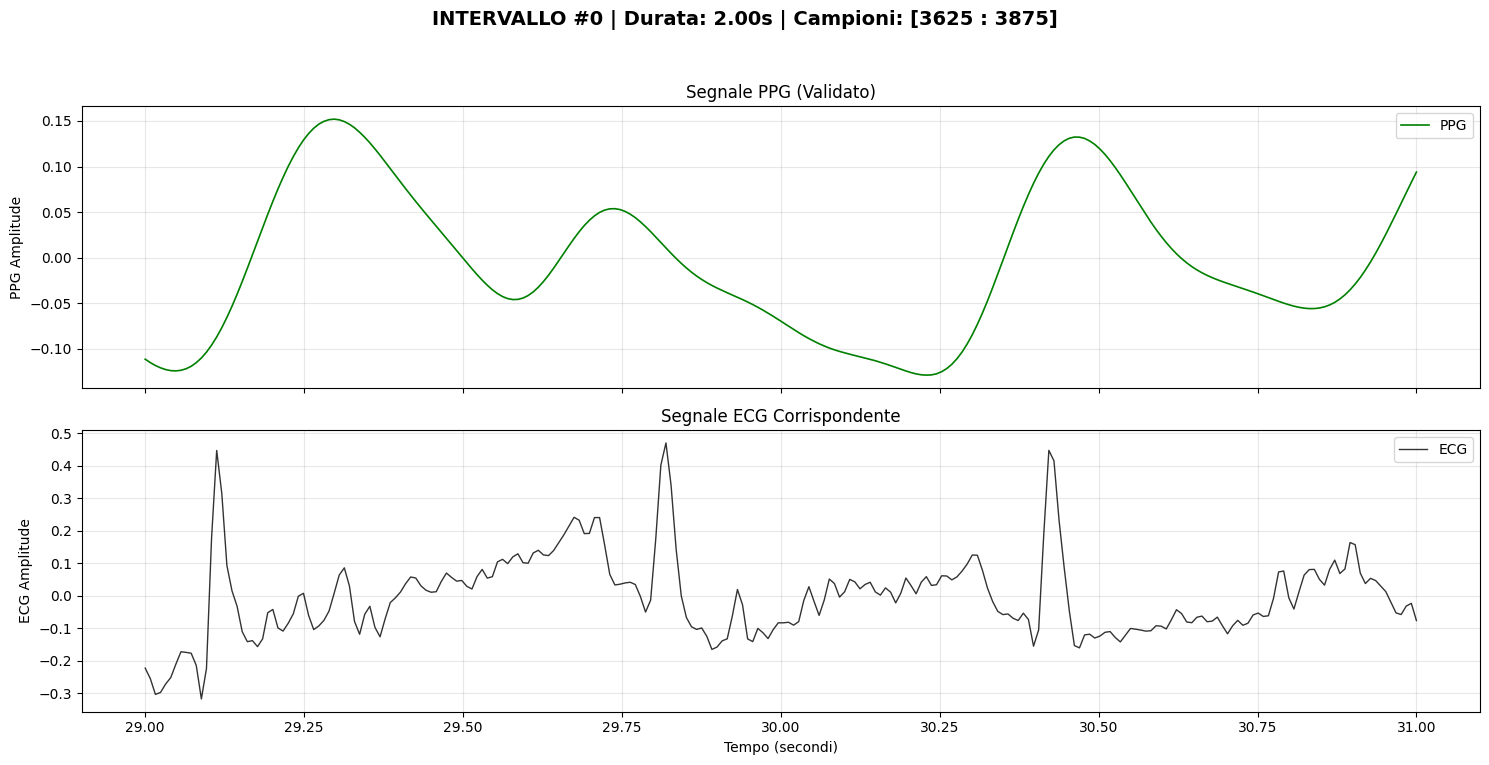

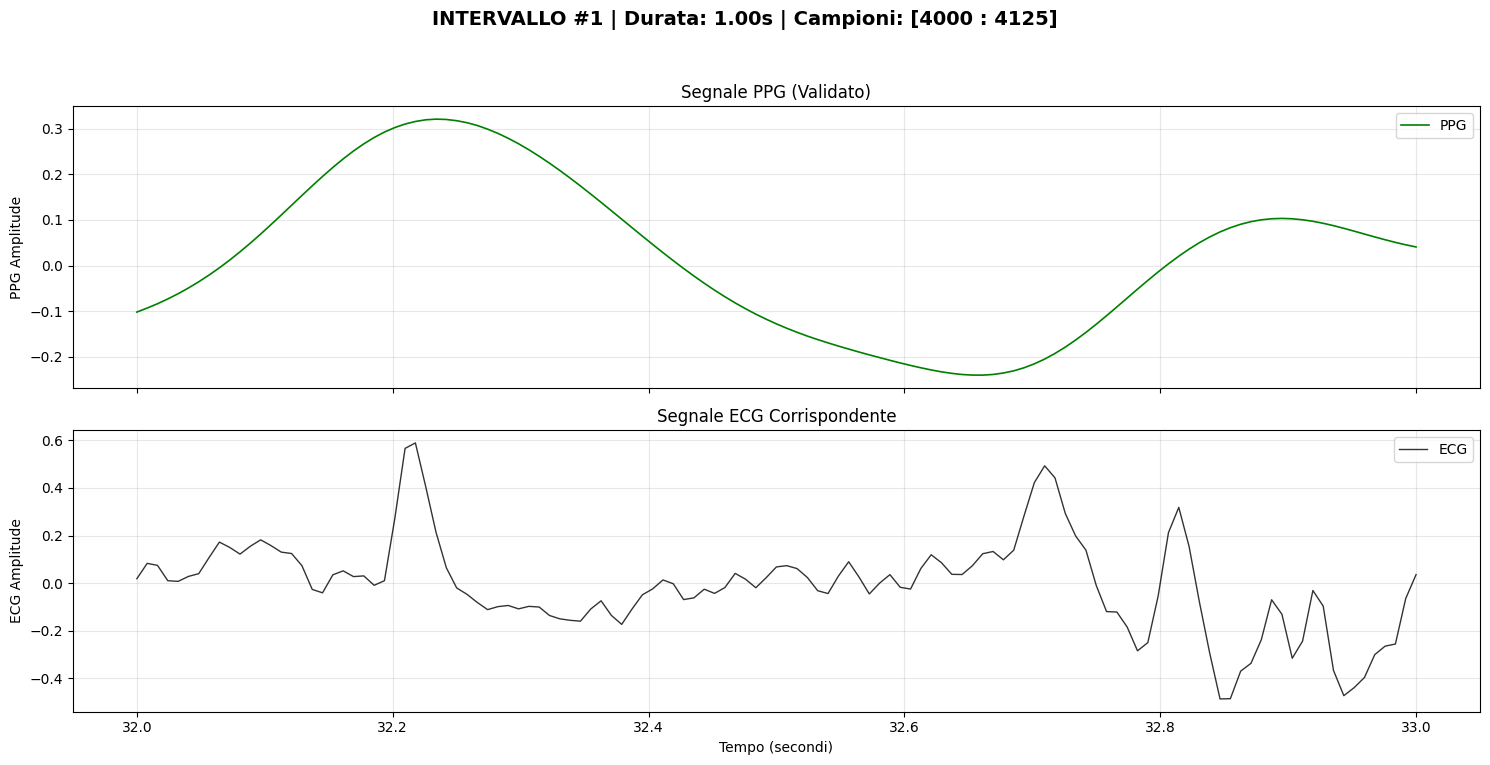

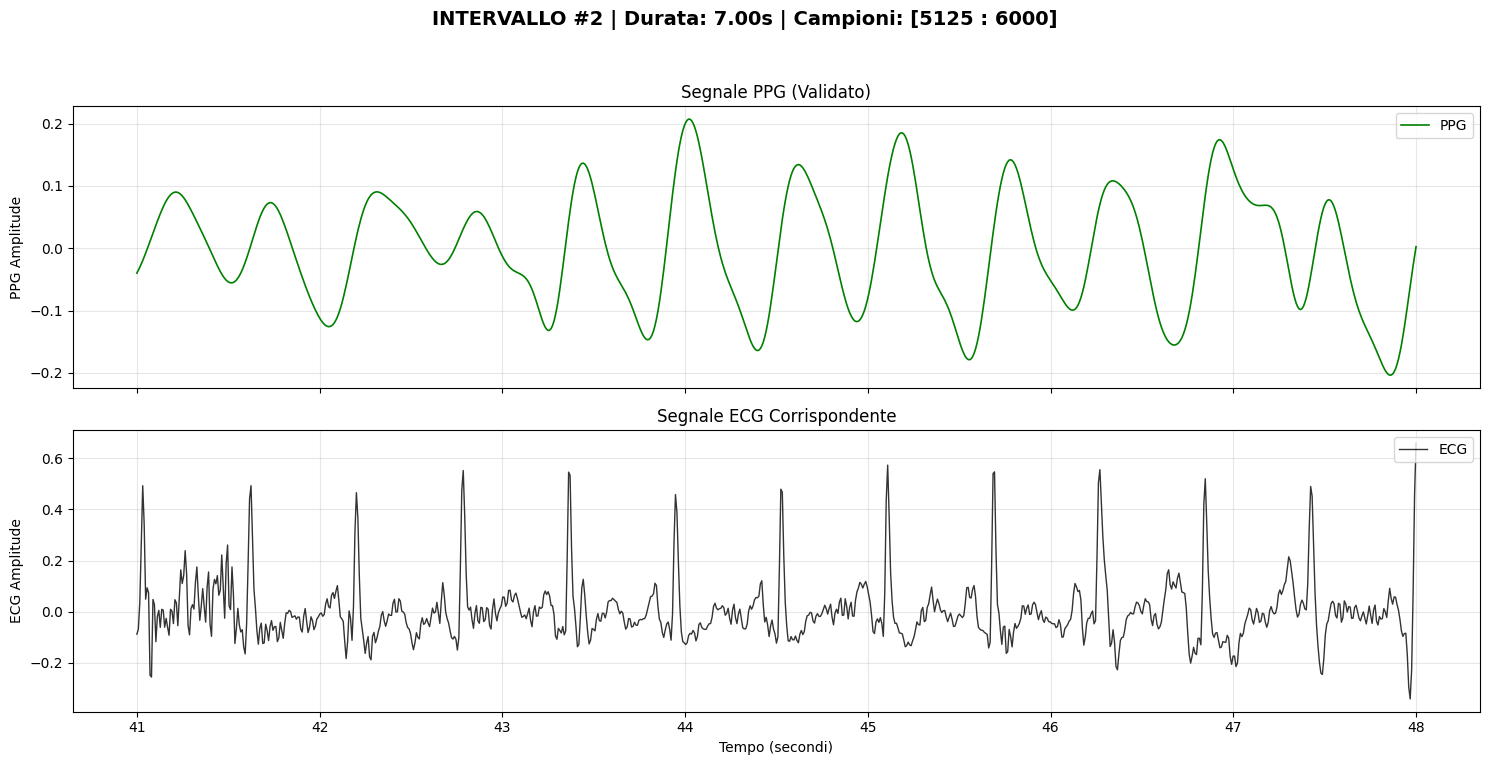

In [90]:
if data_p2:
    ppg_i, ecg_i, comb_i = cross_check_analysis(
        data_p2, win_sec=WINDOW_SIZE, step_sec=SLIDING_STEP, 
        ppg_thr=PPG_THRESHOLD, ecg_thr=ECG_THRESHOLD
    )
    
    # Stampa Statistiche
    print_cross_stats(data_p2, ppg_i, ecg_i, comb_i, "Paziente 2")
    
    # Plotting degli intervalli combinati (es. i primi 3 utili)
    if comb_i:
        # Seleziona i primi 3 indici o quelli che desideri, es: [0, 1, 2]
        indici_da_plottare = list(range(min(3, len(comb_i))))
        plot_specific_intervals(data_p2, comb_i, indici_da_plottare)
    else:
        print("Nessun intervallo combinato trovato per il plotting.")